<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
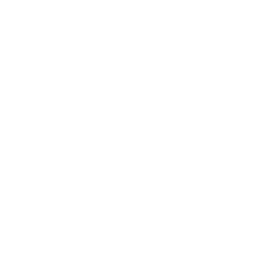
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Wykorzystanie zasobów oddziałów szpitala — wykres słupkowy poziomy</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Opieka zdrowotna / Zarządzanie szpitalem &nbsp;|&nbsp; Marzec 2026</p>
</div>
</div>
</div>

## Streszczenie

Ten przykład wykorzystuje wykresy słupkowe poziome (HBAR) **PROC GCHART** do zobrazowania godzin pracy personelu w sześciu oddziałach klinicznych w Q1 2026. Syntetyczny dziennik kadrowy **90 rekordów zmian** (15 na oddział) zasila trzy widoki: ranking łącznych godzin, średnią długość zmiany na oddział oraz zgrupowane HBAR-y dzielące każdy oddział według kategorii zasobów i według zmiany. `SUMVAR=` sumuje rzeczywiste godziny pracy zamiast liczyć rekordy, `TYPE=SUM`/`TYPE=MEAN` przełącza statystykę odpowiedzi, `DESCENDING` rankinguje oddziały, a `GROUP=` rysuje sąsiadujące zgrupowane słupki dla drugiego wymiaru.

Wynik wspiera kwartalny przegląd efektywności operacyjnej: pokazuje, które oddziały pochłaniają najwięcej pracy, które mają najdłuższe zmiany, oraz jak wzór obsady dzień/popołudnie/noc różni się między oddziałami o ciągłej ostrości a usługami dziennymi.

## Źródła danych

| Źródło | Opis | Rekordy |
|--------|-------------|--------|
| WORK.STAFFING_LOG | Indywidualne rekordy godzin pracy w zmianach | 90 |
| WORK.DEPT_SUMMARY | Sumy na poziomie oddziału i średnia długość zmiany | 6 |

---

In [1]:
/* --------------------------------------------------------
   Wygeneruj syntetyczny dziennik godzin pracy personelu
   szpitalnego. Q1 2026: 6 oddzialow klinicznych, 4 kategorie
   zasobow, 3 zmiany. Rozmiar 15 rekordow zmian na oddzial
   (90 lacznie), aby caly zestaw oddzialow pozostal widoczny.
   -------------------------------------------------------- */
DANE work.staffing_log;
    CALL streaminit(20260601);
    DŁUGOŚĆ department $20 resource_type $24 shift $12;

    /* mix wag kategorii zasobow (obsada z przewaga pielegniarska) */
    TABLICA resw[4] _temporary_ (0.50 0.20 0.20 0.10);

    /* bazowy mix zmian, przechylony w strone Nocy dla oddzialow calodobowych */
    TABLICA shfw[3] _temporary_ (0.45 0.30 0.25);
    TABLICA nightlift[6] _temporary_
        (0.18 0.00 0.22 -0.05 -0.05 0.05);

    POWTÓRZ di = 1 TO 6;
        JEŚLI di = 1 WTEDY department = "SOR";
        PRZECIWNIE JEŚLI di = 2 WTEDY department = "Chirurgia";
        PRZECIWNIE JEŚLI di = 3 WTEDY department = "OIOM";
        PRZECIWNIE JEŚLI di = 4 WTEDY department = "Pediatria";
        PRZECIWNIE JEŚLI di = 5 WTEDY department = "Onkologia";
        PRZECIWNIE department = "Położnictwo";

        POWTÓRZ rec = 1 TO 15;

            /* typ zasobu poprzez losowanie wazone */
            u = rand('uniform'); cum = 0;
            POWTÓRZ r = 1 TO 4;
                cum + resw[r];
                JEŚLI u <= cum WTEDY POWTÓRZ;
                    JEŚLI r = 1 WTEDY resource_type = "Pielęgniarski";
                    PRZECIWNIE JEŚLI r = 2 WTEDY resource_type = "Lekarski";
                    PRZECIWNIE JEŚLI r = 3 WTEDY resource_type = "Personel pomocniczy";
                    PRZECIWNIE resource_type = "Obsługa";
                    OPUŚĆ;
                KONIEC;
            KONIEC;

            /* zmiana wedlug przechylenia nocnego specyficznego dla oddzialu */
            w1 = shfw[1] - nightlift[di] / 2;
            w2 = shfw[2] - nightlift[di] / 2;
            u = rand('uniform');
            JEŚLI u <= w1 WTEDY shift = "Dzień";
            PRZECIWNIE JEŚLI u <= w1 + w2 WTEDY shift = "Popołudnie";
            PRZECIWNIE shift = "Noc";

            /* godziny: lekarze i chirurgia maja dluzsze zmiany */
            BASE = 8;
            JEŚLI resource_type = "Lekarski" WTEDY BASE = BASE + 1.5;
            JEŚLI department = "Chirurgia"   WTEDY BASE = BASE + 1.0;
            hours_worked = round(BASE + rand('normal', 0, 0.8), 0.25);
            JEŚLI hours_worked < 4 WTEDY hours_worked = 4;

            WYJŚCIE;
        KONIEC;
    KONIEC;
    ZACHOWAJ department resource_type shift hours_worked;
WYKONAJ;


NOTE: DATA work.staffing_log


NOTE: Wrote work.staffing_log (90 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


In [2]:
/* --------------------------------------------------------
   Sumy na poziomie oddzialu i srednia dlugosc zmiany,
   uszeregowane wedlug lacznych godzin pracy.
   -------------------------------------------------------- */
PROCEDURA SQL;
    CREATE TABLE work.dept_summary AS
    WYBIERZ department,
           sum(hours_worked)  AS total_hours   format=8.2,
           count(*)           AS shift_count,
           mean(hours_worked) AS avg_shift_hrs  format=6.2
    FROM work.staffing_log
    GROUP WEDŁUG department
    ORDER WEDŁUG total_hours DESC;
QUIT;

PROCEDURA DRUKUJ DANE=work.dept_summary noobs ETYKIETA;
    ETYKIETA department    = "Oddział"
          total_hours   = "Łączne godziny"
          shift_count   = "Liczba zmian"
          avg_shift_hrs = "Średnia zmiana (godz.)";
    TYTUŁ "Podsumowanie godzin pracy wg oddziału - Q1 2026";
WYKONAJ;
TYTUŁ;

                                    Podsumowanie godzin pracy wg oddziału - Q1 2026                                     

      Oddział    Łączne godziny  Liczba zmian   Średnia zmiana (godz.)
Chirurgia                136.25            15                     9.08
OIOM                     128.50            15                     8.57
Położnictwo              127.75            15                     8.52
Pediatria                124.75            15                     8.32
Onkologia                123.75            15                     8.25
SOR                      119.25            15                     7.95




NOTE: PROC SQL 

NOTE: Table work.dept_summary created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=work.dept_summary

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


---

                                               Godziny pracy wg oddziału                                                

                                                  The MEANS Procedure

                                 Analysis Variable : hours_worked Godziny przepracowane

        Oddział                  Sum           Mean          N Obs
        ----------------------------------------------------------
        Chirurgia             136.25           9.08             15
        OIOM                  128.50           8.57             15
        Onkologia             123.75           8.25             15
        Pediatria             124.75           8.32             15
        Położnictwo           127.75           8.52             15
        SOR                   119.25           7.95             15
        ----------------------------------------------------------

                                               Rozkład zmian wg oddziału                                          


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_department_shift.spec.json
NOTE: PROC FREQ statement used.


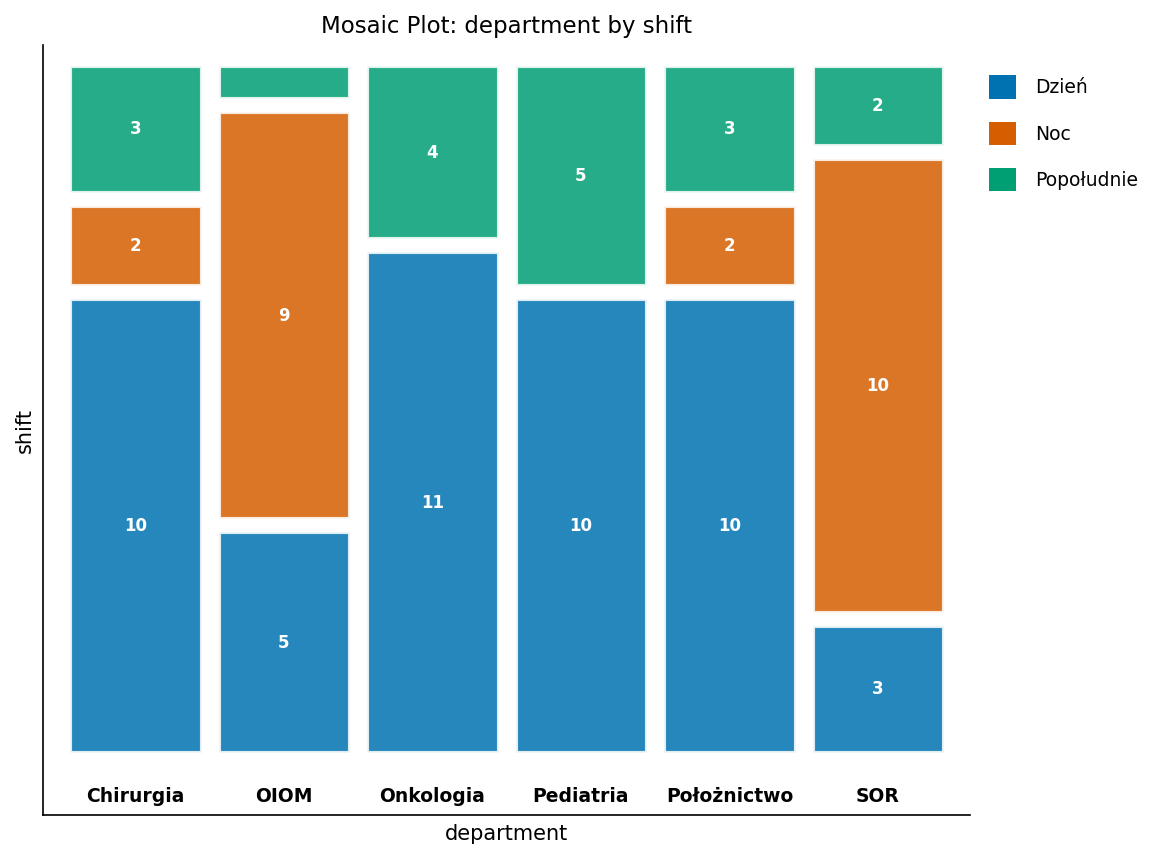

In [3]:
/* --------------------------------------------------------
   Tabele wyjsciowe: godziny pracy wg oddzialu oraz rozklad
   zmian dzien / popoludnie / noc na oddzial.
   -------------------------------------------------------- */
PROCEDURA ŚREDNIE DANE=work.staffing_log sum mean n maxdec=2;
    KLASA department;
    ZMIENNA hours_worked;
    ETYKIETA department="Oddział" hours_worked="Godziny przepracowane";
    TYTUŁ "Godziny pracy wg oddziału";
WYKONAJ;

PROCEDURA CZĘSTOŚCI DANE=work.staffing_log;
    TABLES department * shift / norow nocol nopercent;
    ETYKIETA department="Oddział" shift="Zmiana";
    TYTUŁ "Rozkład zmian wg oddziału";
WYKONAJ;
TYTUŁ;

---


NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


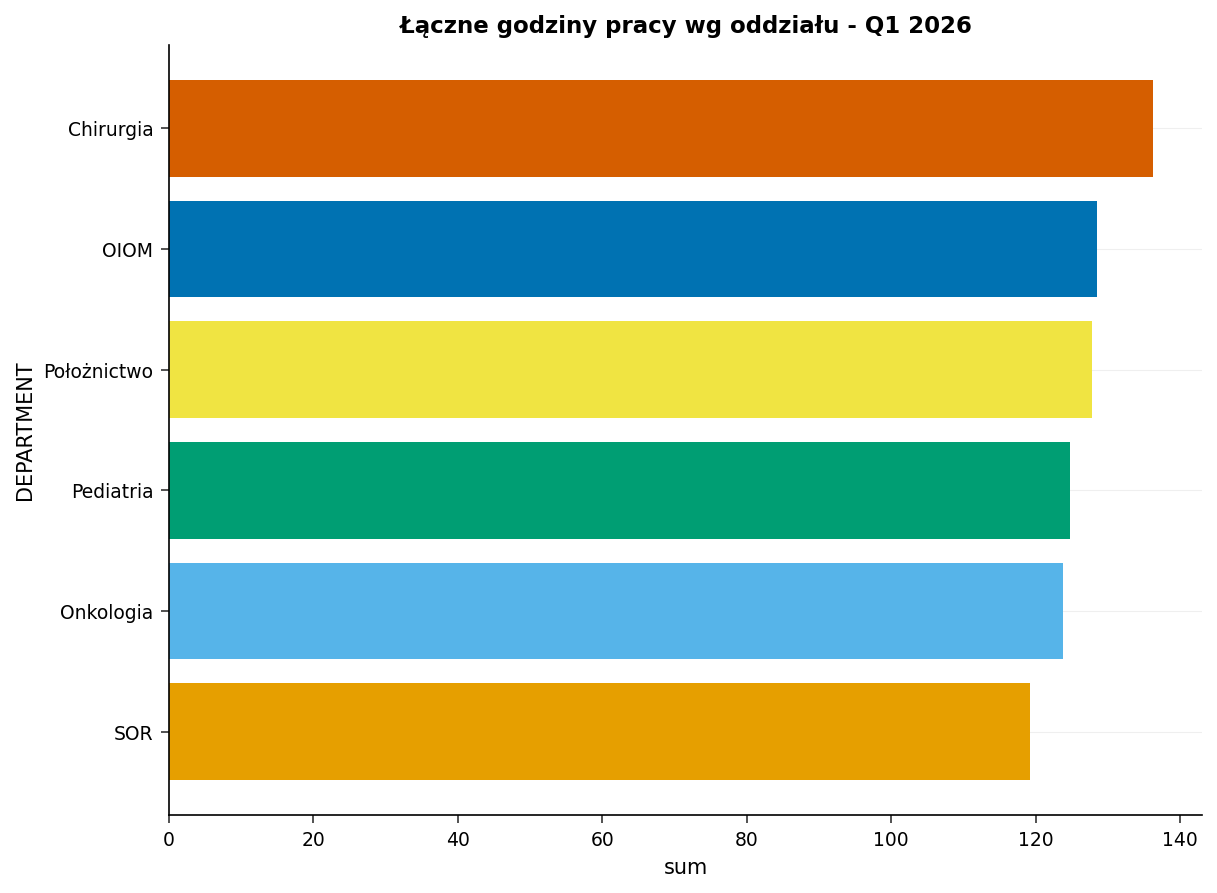

In [4]:
/* --------------------------------------------------------
   HBAR przegladowy: laczne godziny pracy wg oddzialu.
   SUMVAR= sumuje godziny; DESCENDING rankinguje slupki.
   -------------------------------------------------------- */
PROCEDURA GCHART DANE=work.staffing_log;
    HBAR department / SUMVAR=hours_worked
                      type=sum
                      MALEJĄCO;
    TYTUŁ "Łączne godziny pracy wg oddziału - Q1 2026";
WYKONAJ;
QUIT;
TYTUŁ;

### Podział każdego oddziału według kategorii zasobów

`GROUP=` rysuje klaster sąsiadujących słupków poziomych dla każdego oddziału, po jednym słupku na kategorię zasobów. Ponieważ obowiązuje `SUMVAR=hours_worked`, każdy słupek mierzy skumulowane godziny pracy, a nie liczbę rekordów, więc wykres pokazuje, jak godziny pielęgniarskie, lekarskie, personelu pomocniczego i obsługi porównują się *w obrębie* każdego oddziału.

In [5]:
/* --------------------------------------------------------
   Instrukcje PATTERN: skoordynowana paleta 4 kolorow,
   jeden wzor na podgrupe typu zasobu
   -------------------------------------------------------- */
pattern1 VALUE=solid color=cx2C5F8A;   /* Pielegniarski -- glebki niebieski */
pattern2 VALUE=solid color=cx28A745;   /* Lekarski -- zielony */
pattern3 VALUE=solid color=cxE8650A;   /* Personel pomocniczy -- bursztynowy */
pattern4 VALUE=solid color=cx6C757D;   /* Obsluga -- szary */

                                      Godziny pracy oddziałów wg kategorii zasobu                                       


Źródło: System Zarządzania Kadrami | Okres raportowania: Sty-Mar 2026



NOTE: Option TITLE changed to Godziny pracy oddziałów wg kategorii zasobu.
NOTE: Option FOOTNOTE changed to Źródło: System Zarządzania Kadrami | Okres raportowania: Sty-Mar 2026.
NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


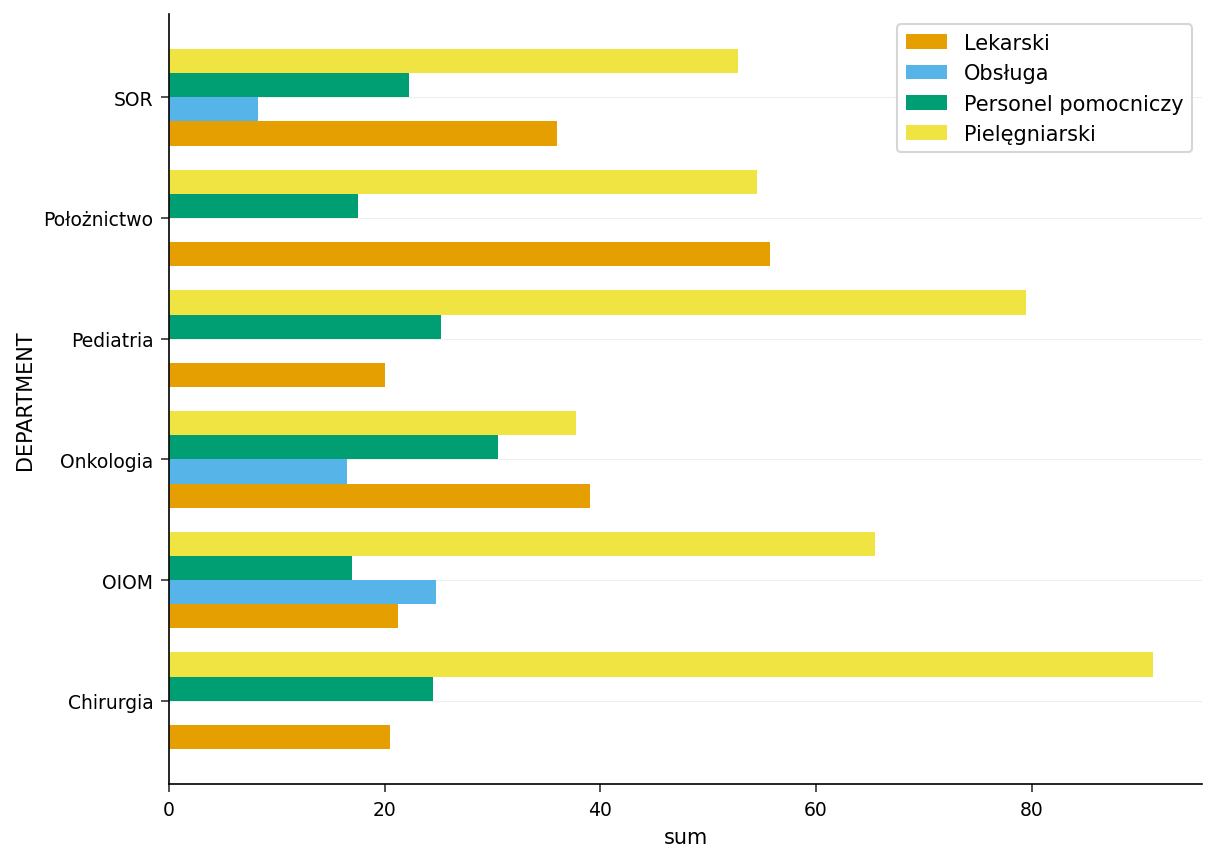

In [6]:
/* --------------------------------------------------------
   HBAR zgrupowany wedlug kategorii zasobu (GROUP=).
   Kazdy oddzial staje sie klastrem slupkow -- po jednym na
   typ zasobu -- mierzonych w skumulowanych godzinach pracy.
   -------------------------------------------------------- */
TYTUŁ "Godziny pracy oddziałów wg kategorii zasobu";
footnote JUSTIFY=LEFT
    "Źródło: System Zarządzania Kadrami | Okres raportowania: Sty-Mar 2026";

PROCEDURA GCHART DANE=work.staffing_log;
    HBAR department / GROUP=resource_type
                      SUMVAR=hours_worked
                      type=sum;
WYKONAJ;
QUIT;

TYTUŁ; footnote;

                                           Godziny pracy oddziałów wg zmiany                                            


Zgrupowane słupki rozdzielają udziały Dnia / Popołudnia / Nocy na oddział



NOTE: Option TITLE changed to Godziny pracy oddziałów wg zmiany.
NOTE: Option FOOTNOTE changed to Zgrupowane słupki rozdzielają udziały Dnia / Popołudnia / Nocy na oddział.
NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


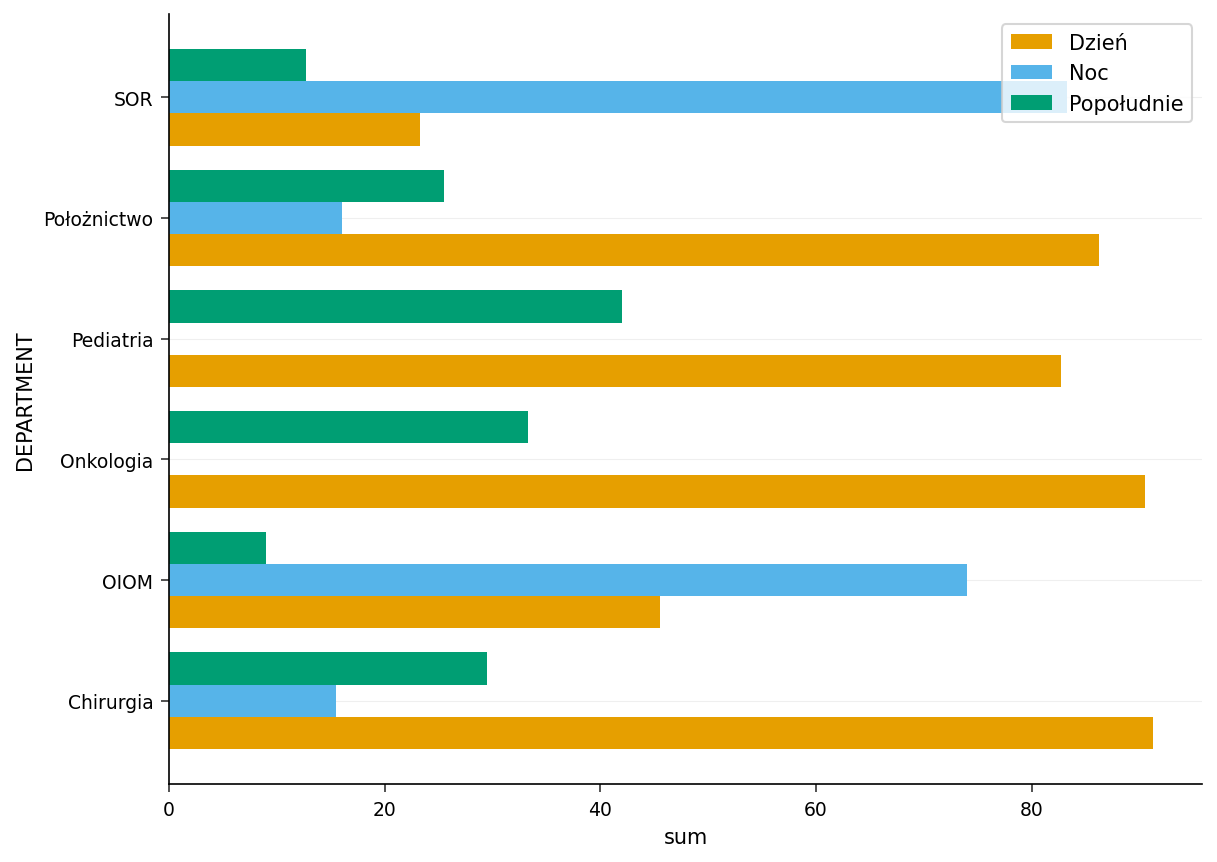

In [7]:
/* --------------------------------------------------------
   HBAR zgrupowany wedlug zmiany (GROUP=).
   Rozdziela godziny pracy Dzien / Popoludnie / Noc w obrebie
   kazdego oddzialu -- podkreslajac oddzialy calodobowe.
   -------------------------------------------------------- */
TYTUŁ "Godziny pracy oddziałów wg zmiany";
footnote JUSTIFY=LEFT
    "Zgrupowane słupki rozdzielają udziały Dnia / Popołudnia / Nocy na oddział";

PROCEDURA GCHART DANE=work.staffing_log;
    HBAR department / GROUP=shift
                      SUMVAR=hours_worked
                      type=sum;
WYKONAJ;
QUIT;

TYTUŁ; footnote;


NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


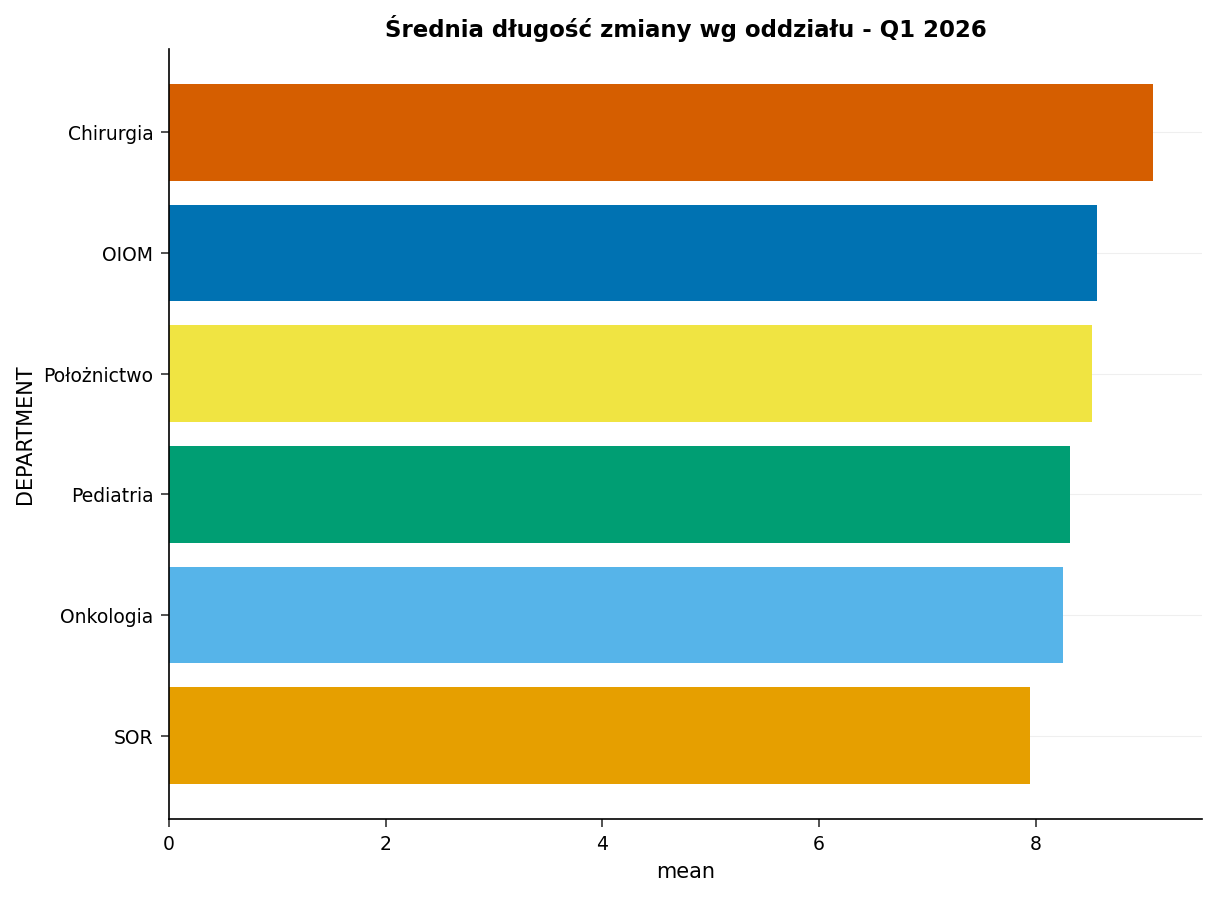

In [8]:
/* --------------------------------------------------------
   Srednia dlugosc zmiany na oddzial (TYPE=MEAN).
   Pokazuje, czy oddzial ma dluzsze zmiany, czy wiecej
   krotszych, niezaleznie od calkowitego wolumenu.
   -------------------------------------------------------- */
PROCEDURA GCHART DANE=work.staffing_log;
    HBAR department / SUMVAR=hours_worked
                      type=mean
                      MALEJĄCO;
    TYTUŁ "Średnia długość zmiany wg oddziału - Q1 2026";
WYKONAJ;
QUIT;
TYTUŁ;

---

### Interpretacja

W 90 rekordach zmian, łączne godziny pracy mieszczą się w wąskim paśmie od **119,25** (SOR) do **136,25** (Chirurgia), ponieważ każdy oddział ma tę samą liczbę 15 zmian w tym okresie — więc ranking odzwierciedla **długość zmiany**, a nie liczbę zmian. Chirurgia jest liderem zarówno na wykresie łącznych godzin, jak i średniej zmiany, przy **9,08 godziny** na zmianę, co jest zgodne z dłuższymi przypadkami operacyjnymi i wymaganą przez nie obsadą z przewagą lekarzy. SOR znajduje się na dole według godzin (średnia **7,95**) mimo bycia jednym z najbardziej obciążonych oddziałów, ponieważ jego praca jest realizowana w krótszych zmianach o wyższej rotacji.

Zgrupowany według zmiany HBAR i panel mozaikowy opowiadają ważną operacyjnie historię. **SOR i OIOM są zdominowane przez noc** — odpowiednio 10 z 15 i 9 z 15 zmian przypada na Noc — podczas gdy **Onkologia i Pediatria nie mają w ogóle zmian Nocnych** i koncentrują się na pokryciu Dnia (odpowiednio 11 i 10 zmian Dnia). Ten podział odzwierciedla rzeczywistą obsadę szpitalną: oddziały o ciągłej ostrości działają całą dobę, podczas gdy infuzje onkologiczne i ogólna pediatria to usługi dzienne. Panel kategorii zasobów potwierdza **mix z przewagą pielęgniarską** w każdym oddziale, przy czym godziny lekarskie i personelu pomocniczego tworzą drugorzędne warstwy.

Dla przeglądu obsady Q2, koncentracja zmian nocnych w SOR i OIOM to pozycja do obserwowania: to tam kumulują się koszty stawek premiowych i zarządzania zmęczeniem oraz gdzie każda zmiana rotacji ma największy wpływ budżetowy.

---

In [9]:
/* --------------------------------------------------------
   Eksportuj podsumowanie oddzialu dla systemu planowania
   kadr.
   -------------------------------------------------------- */
PROCEDURA EKSPORTUJ DANE=work.dept_summary
    OUTFILE='q1_dept_labor_summary.csv'
    DBMS=csv REPLACE;
WYKONAJ;


NOTE: PROC EXPORT data=work.dept_summary outfile=q1_dept_labor_summary.csv

NOTE: Exported 6 rows to q1_dept_labor_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Poufne
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Napędzane przez <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>